In [1]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from utils import readQuotes, parabolic_sar, EMA, ATR

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = readQuotes('..\download_data\CHMF_30MIN_history.txt')

In [4]:
df['sar'] = parabolic_sar(df['high'], df['low'])

In [6]:
import datetime
import enum
from typing import List

class PositionDirection(enum.Enum):
    buy = 'buy'
    sell = 'sell'
    cash = 'cash'

    def __str__(self):
        return str(self.value)


class Position:
    def __init__(
        self, direction: PositionDirection,
        open_time: datetime,
        open: float,
        close: float = None,
        close_time: datetime = None
    ):
        self.direction = direction
        self.open_time = open_time
        self.open = open
        self.close = close
        self.close_time = close_time


In [7]:
import matplotlib.pyplot as plt

def calculate_cumulative_pnl(positions):
    # Фильтруем только закрытые позиции (у которых есть close_time и close)
    closed_positions = [p for p in positions if p.close_time is not None and p.close is not None]
    
    # Сортируем по времени закрытия
    closed_positions.sort(key=lambda x: x.close_time)
    
    # Рассчитываем PnL для каждой сделки
    pnl = []
    dates = []
    cumulative = 0
    
    for position in closed_positions:
        if position.direction == PositionDirection.buy:
            trade_pnl = position.close - position.open
        elif position.direction == PositionDirection.sell:
            trade_pnl = position.open - position.close
        else:  # cash
            trade_pnl = 0
        
        cumulative += trade_pnl
        pnl.append(cumulative)
        dates.append(position.close_time)
    
    return dates, pnl

def plot_cumulative_pnl(dates, pnl):
    plt.figure(figsize=(12, 6))
    plt.plot(dates, pnl, marker='o', linestyle='-')
    plt.title('Кумулятивный PnL сделок')
    plt.xlabel('Дата закрытия')
    plt.ylabel('Кумулятивный PnL')
    plt.grid(True)
    plt.axhline(y=0, color='black', linestyle='--')
    plt.tight_layout()
    plt.show()

In [8]:
from functools import lru_cache

@lru_cache(maxsize=None)
def cached_ema(close_series: tuple, period: int):
    return EMA(pd.Series(close_series), period)

@lru_cache(maxsize=None)
def cached_atr(df_hash: str, period: int):
    # Преобразуем DataFrame в hashable тип
    return ATR(df, period)

In [9]:
def optimize_df(df):
    # Конвертируем в numpy arrays для быстрого доступа
    return {
        'open': df['open'].values,
        'high': df['high'].values,
        'low': df['low'].values,
        'close': df['close'].values,
        'ema': df['ema'].values,
        'atr': df['atr'].values,
        'sar': df['sar'].values,
        'index': df.index
    }

In [46]:
import pickle
from tqdm import tqdm
from typing import Dict, List
import pandas as pd


def save_progress(data: Dict, filename: str = 'progress.pkl'):
    """Сохраняет текущий прогресс в pickle файл"""
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

def load_progress(filename: str = 'progress.pkl') -> Dict:
    """Загружает прогресс из pickle файла"""
    try:
        with open(filename, 'rb') as f:
            return pickle.load(f)
    except FileNotFoundError:
        return {}

def should_open_buy_position(df: Dict, i: int) -> bool:
    """Определяет условия для открытия длинной позиции"""
    return (
        df['sar'][i-2] > df['high'][i-2] and 
        df['sar'][i-2] > df['ema'][i-2] and 
        df['sar'][i-1] < df['low'][i-1] and 
        df['sar'][i-1] > df['ema'][i-1] and 
        df['open'][i] > df['sar'][i-1] and 
        df['open'][i] > df['ema'][i]
    )

def should_open_sell_position(df: pd.DataFrame, i: int) -> bool:
    """Определяет условия для открытия короткой позиции"""
    return (
        df['sar'][i-2] < df['low'][i-2] and
        df['sar'][i-2] < df['ema'][i-2] and
        df['sar'][i-1] > df['high'][i-1] and 
        df['sar'][i-1] < df['ema'][i-1] and
        df['open'][i] < df['sar'][i-1] and 
        df['open'][i] < df['ema'][i]
    )

def should_close_buy_position(position: Position, df: Dict, i: int, 
                            coef_prof: float, coef_loss: float) -> bool:
    """Определяет условия для закрытия длинной позиции"""
    return (position.open + coef_prof * df['atr'][i] < df['high'][i] or
            position.open - coef_loss * df['atr'][i] > df['low'][i])

def should_close_sell_position(position: Position, df: pd.DataFrame, i: int,
                             coef_prof: float, coef_loss: float) -> bool:
    """Определяет условия для закрытия короткой позиции"""
    return (position.open - coef_prof * df['atr'][i] > df['low'][i] or
            position.open + coef_loss * df['atr'][i] < df['high'][i])

def process_positions(df: Dict[str, np.array], coef_prof: float, coef_loss: float) -> List[Position]:
    """Обрабатывает все позиции для текущих параметров"""
    cur_direction = PositionDirection.cash
    list_positions = []
    cur_position = None

    for i in range(2, df['index'].size):
        if cur_direction == PositionDirection.cash:
            if should_open_buy_position(df, i):
                cur_direction = PositionDirection.buy
                cur_position = Position(
                    direction=PositionDirection.buy,
                    open=df['open'][i],
                    open_time=df['index'][i]
                )
            elif should_open_sell_position(df, i):
                cur_direction = PositionDirection.sell
                cur_position = Position(
                    direction=PositionDirection.sell,
                    open=df['open'][i],
                    open_time=df['index'][i]
                )
        else:
            if (cur_position.direction == PositionDirection.buy and 
                should_close_buy_position(cur_position, df, i, coef_prof, coef_loss)):
                
                if cur_position.open + coef_prof * df['atr'][i] < df['high'][i]:
                    cur_position.close = cur_position.open + coef_prof * df['atr'][i]
                else:
                    cur_position.close = cur_position.open - coef_loss * df['atr'][i]
                
                cur_position.close_time = df['index'][i]
                list_positions.append(cur_position)
                cur_position = None
                cur_direction = PositionDirection.cash
            
            elif (cur_position.direction == PositionDirection.sell and 
                  should_close_sell_position(cur_position, df, i, coef_prof, coef_loss)):
                
                if cur_position.open - coef_prof * df['atr'][i] > df['low'][i]:
                    cur_position.close = cur_position.open - coef_prof * df['atr'][i]
                else:
                    cur_position.close = cur_position.open + coef_loss * df['atr'][i]
                
                cur_position.close_time = df['index'][i]
                list_positions.append(cur_position)
                cur_position = None
                cur_direction = PositionDirection.cash

    return list_positions

def run_backtest(
    df: pd.DataFrame, 
    ema_range: range = range(25, 31, 5),
    atr_range: range = range(4, 6),
    coef_prof_range: range = range(2, 4),
    coef_loss_range: range = range(2, 4),
    filename: str = 'progress.pkl',
) -> Dict:
    # period_ema=30:period_atr=5:coef_prof=2:coef_loss=2
    """Основная функция для запуска бэктеста"""
    results = load_progress(filename=filename)
    
    try:
        for period_ema in tqdm(ema_range, desc="EMA Progress"):
            df['ema'] = EMA(df['close'], period=period_ema)
            
            for period_atr in atr_range:
                df['atr'] = ATR(df, period=period_atr)
                
                for coef_prof in coef_prof_range:
                    for coef_loss in coef_loss_range:
                        if coef_prof/coef_loss > 1.4:
                            key = f'{period_ema=}:{period_atr=}:{coef_prof=}:{coef_loss=}'
                            opt_df = optimize_df(df)
                            
                            # Пропускаем уже рассчитанные параметры
                            if key in results:
                                continue
                                
                            positions = process_positions(opt_df, coef_prof, coef_loss)
                            results[key] = positions
                            
                            # Сохраняем прогресс после каждой итерации
                            save_progress(results, filename)
    except Exception as e:
        print(f"Произошла ошибка: {str(e)}")
        print("Сохраняем текущий прогресс перед выходом...")
        save_progress(results, filename)
        raise
    
    return results


In [47]:
results = run_backtest(
    df,
    ema_range=range(20, 25, 1),
    atr_range=range(4, 14),
    coef_prof_range=range(1, 9),
    coef_loss_range=range(1, 9),
    filename='pickle/opti_CHMF_30Min.pickle'
)

EMA Progress: 100%|██████████| 5/5 [25:34<00:00, 306.92s/it]


In [49]:
results = load_progress('pickle/opti_CHMF_30Min.pickle')

In [50]:
len(results.keys())

2850

In [51]:
def best_model(results: Dict):
    best = (0, 0)
    for k, v in results.items():
        d, pnl = calculate_cumulative_pnl(v)
        if len(pnl) > 0 and pnl[-1] > best[1]:
            best = (k, pnl[-1])
    return best

In [52]:
def foo(results):
    pl = 0
    ll = 0
    for i in results:
        if i.direction == PositionDirection.buy and ((i.close - i.open) > 0):
            pl += 1
        elif i.direction == PositionDirection.sell and ((i.open - i.close) > 0):
            pl += 1
        else:
            ll += 1
    return pl, ll, pl/(pl+ll)

def best_winrate(results: Dict):
    best_rate = (0, 0)
    for k, v in results.items():
        _, _, rate = foo(v)
        if rate > best_rate[1]:
            best_rate = (k, rate)

    return best_rate

In [53]:
best_model = best_model(results)
best_model

('period_ema=40:period_atr=12:coef_prof=7:coef_loss=3', 347.5155849239519)

In [65]:
b_win = best_winrate(results)
b_win

('period_ema=20:period_atr=5:coef_prof=3:coef_loss=2', 0.5862068965517241)

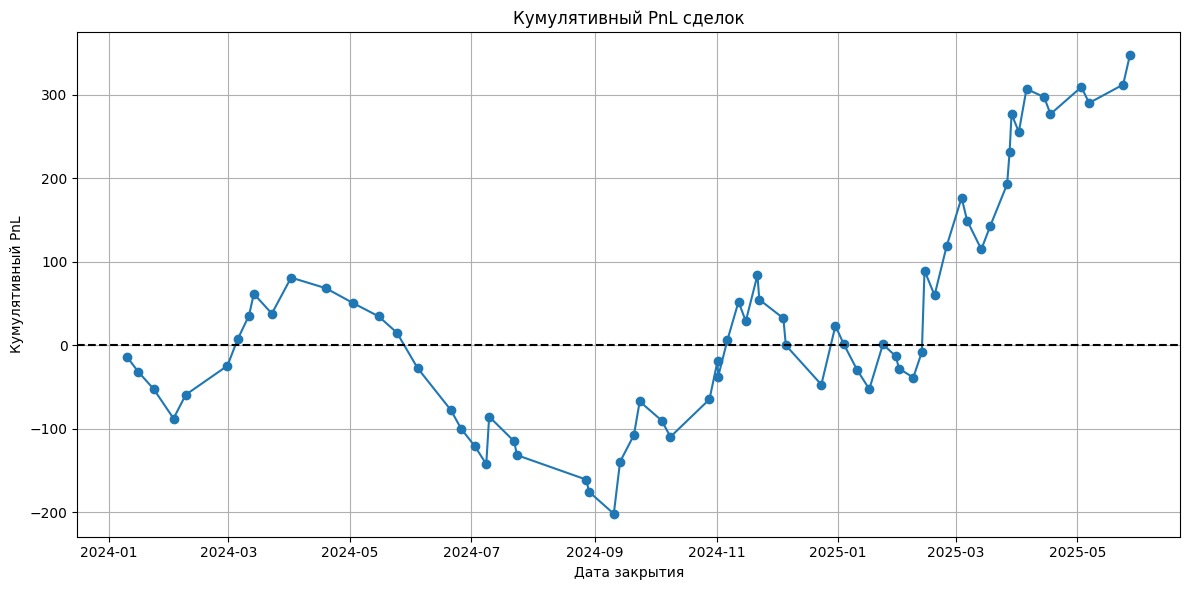

In [55]:
d, pnl = calculate_cumulative_pnl(results[best_model[0]])
plot_cumulative_pnl(d, pnl)

In [36]:
pl = 0
ll = 0
for i in results[best_model[0]]:
    if i.direction == PositionDirection.buy and ((i.close - i.open) > 0):
        pl += 1
    elif i.direction == PositionDirection.sell and ((i.open - i.close) > 0):
        pl += 1
    else:
        ll += 1
    
print(f'Удача {pl}')
print(f'Не удача {ll}')
print(f'Winrate {pl/(pl+ll)}')

Удача 29
Не удача 40
Winrate 0.42028985507246375


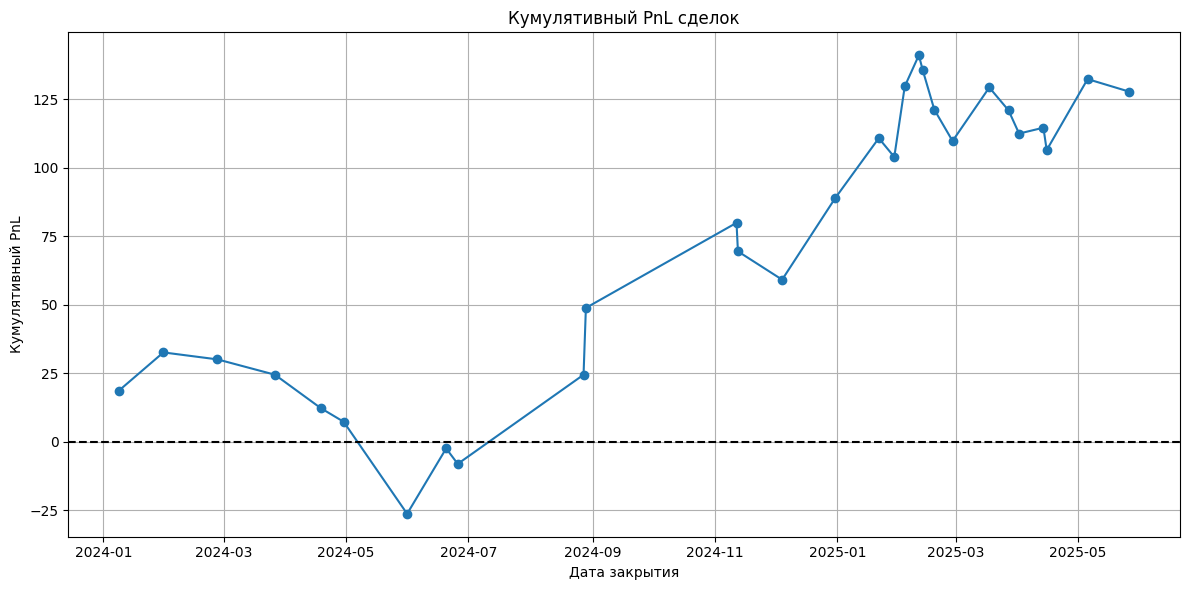

In [37]:
d, pnl = calculate_cumulative_pnl(results[b_win[0]])
plot_cumulative_pnl(d, pnl)

In [38]:
foo(results[b_win[0]])

(13, 16, 0.4482758620689655)

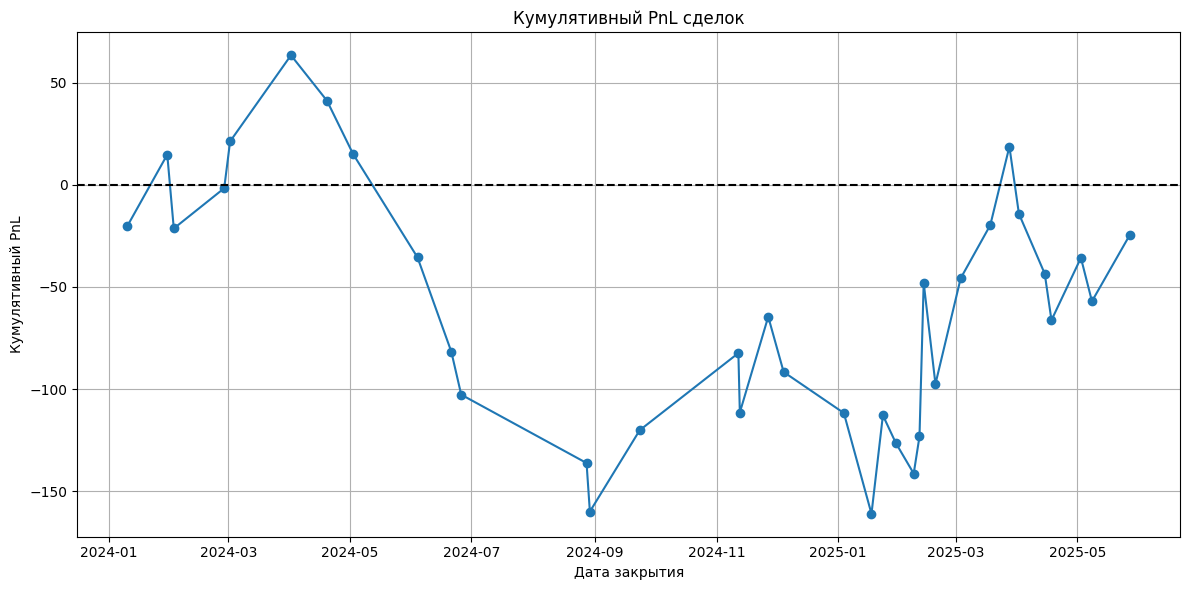

In [61]:
d, pnl = calculate_cumulative_pnl(results['period_ema=21:period_atr=8:coef_prof=6:coef_loss=4'])
plot_cumulative_pnl(d, pnl)

In [64]:
results['period_ema=21:period_atr=8:coef_prof=6:coef_loss=4'][0].__dict__

{'direction': <PositionDirection.buy: 'buy'>,
 'open_time': Timestamp('2024-01-05 23:00:00'),
 'open': 1442.6,
 'close': 1422.4927517415126,
 'close_time': Timestamp('2024-01-10 10:00:00')}

In [67]:
df.loc['2024-11-12']

,open,high,low,close,volume,sar,ema,atr
Date,,,,,,,,
2024-11-12 10:00:00,1269.6,1269.6,1246.0,1250.0,219715,1274.000000,1250.759313,8.148735
2024-11-12 10:30:00,1250.0,1257.4,1248.4,1248.8,108459,1273.440000,1250.602568,8.214217
2024-11-12 11:00:00,1249.0,1259.0,1246.4,1247.4,93320,1272.891200,1250.346363,8.551585
2024-11-12 11:30:00,1247.4,1247.6,1237.6,1241.6,113473,1272.353376,1249.646654,8.663002
2024-11-12 12:00:00,1241.8,1244.4,1238.2,1242.6,103723,1270.963241,1249.082921,8.473540
2024-11-12 12:30:00,1242.0,1249.0,1240.4,1248.0,63778,1269.628711,1248.996288,8.483268
2024-11-12 13:00:00,1248.0,1252.0,1243.6,1246.0,23290,1268.347563,1248.756585,8.476863
2024-11-12 13:30:00,1246.0,1247.8,1241.8,1247.8,16275,1267.117660,1248.680058,8.286335
2024-11-12 14:00:00,1246.6,1248.4,1242.2,1243.2,23253,1265.936954,1248.241653,8.125847


In [68]:
def quik_parabolic_sar(high, low, close, step=0.02, max_step=0.2):
    """
    Вычисление Parabolic SAR как в QUIK
    
    Параметры:
        high (list/np.array): массив максимальных цен
        low (list/np.array): массив минимальных цен
        close (list/np.array): массив цен закрытия
        step (float): шаг изменения фактора ускорения (по умолчанию 0.02)
        max_step (float): максимальное значение фактора ускорения (по умолчанию 0.2)
    
    Возвращает:
        list: значения SAR для каждого периода
    """
    length = len(close)
    if length == 0:
        return []
    
    sar = [None] * length
    ep = [None] * length  # Extreme Price
    af = [None] * length  # Acceleration Factor
    trend = [None] * length  # 1 - long, -1 - short
    
    # Инициализация первых значений
    sar[0] = close[0]
    trend[0] = 1  # Начинаем с длинной позиции
    ep[0] = high[0]  # Для длинной позиции EP - максимальная цена
    af[0] = step
    
    for i in range(1, length):
        # 1. Предварительное вычисление SAR для текущего периода
        sar[i] = sar[i-1] + af[i-1] * (ep[i-1] - sar[i-1])
        
        # 2. Проверка на смену тренда
        if trend[i-1] == 1:
            # Если длинная позиция - проверяем на разворот в короткую
            if low[i] < sar[i]:
                trend[i] = -1
                sar[i] = ep[i-1]  # Новый SAR = предыдущий EP
                ep[i] = low[i]
                af[i] = step
            else:
                trend[i] = 1
                # Обновляем EP если новый максимум
                ep[i] = max(high[i], ep[i-1])
                # Увеличиваем AF если обновили EP
                af[i] = min(af[i-1] + step, max_step) if ep[i] > ep[i-1] else af[i-1]
        else:
            # Если короткая позиция - проверяем на разворот в длинную
            if high[i] > sar[i]:
                trend[i] = 1
                sar[i] = ep[i-1]  # Новый SAR = предыдущий EP
                ep[i] = high[i]
                af[i] = step
            else:
                trend[i] = -1
                # Обновляем EP если новый минимум
                ep[i] = min(low[i], ep[i-1])
                # Увеличиваем AF если обновили EP
                af[i] = min(af[i-1] + step, max_step) if ep[i] < ep[i-1] else af[i-1]
        
        # 3. Ограничения SAR для текущего периода
        if trend[i] == 1:
            # Для длинной позиции SAR не может быть выше двух предыдущих минимумов
            if i >= 2:
                sar[i] = min(sar[i], low[i-1], low[i-2])
            elif i >= 1:
                sar[i] = min(sar[i], low[i-1])
        else:
            # Для короткой позиции SAR не может быть ниже двух предыдущих максимумов
            if i >= 2:
                sar[i] = max(sar[i], high[i-1], high[i-2])
            elif i >= 1:
                sar[i] = max(sar[i], high[i-1])
    
    return sar

In [ ]:
sar = quik_parabolic_sar(
    df['high'],
    df['low'],
    df['close']
)


1006.8245833195582

In [81]:
sar[-19:]

[1003.0,
 1003.084,
 1003.3686399999999,
 1003.9585215999999,
 1004.513010304,
 1005.03422968576,
 1005.5241759046144,
 1005.9847253503375,
 1006.4176418293173,
 1006.8245833195582,
 1013.2,
 1013.076,
 1012.95448,
 1012.7083008,
 1012.281802752,
 1011.88089458688,
 1011.5040409116672,
 1010.9837176387338,
 1010.2053458748604]

In [80]:
df['sar'].tail(15)

Date
2025-05-31 11:30:00    1004.513010
2025-05-31 12:00:00    1005.034230
2025-05-31 12:30:00    1005.524176
2025-05-31 13:00:00    1005.984725
2025-05-31 13:30:00    1006.417642
2025-05-31 14:00:00    1006.824583
2025-05-31 14:30:00    1013.200000
2025-05-31 15:00:00    1013.076000
2025-05-31 15:30:00    1012.954480
2025-05-31 16:00:00    1012.708301
2025-05-31 16:30:00    1012.281803
2025-05-31 17:00:00    1011.880895
2025-05-31 17:30:00    1011.504041
2025-05-31 18:00:00    1010.983718
2025-05-31 18:30:00    1010.205346
Name: sar, dtype: float64